# **Numerical Missing Data**

Adavntages :

Simple

Disadvantages :

Change in distribution

Outliers aa jate h

Covarience me changes

When to use:

missing completely at random

less than 5%

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

In [ ]:
df=pd.read_csv("titanic_toy.csv");

In [ ]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [ ]:
df.isnull().mean()

,0
Age,0.198653
Fare,0.050505
Family,0.000000
Survived,0.000000


In [ ]:
x=df.drop("Survived",axis=1)
y=df['Survived']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [ ]:
x_train.isnull().mean()

,0
Age,0.207865
Fare,0.050562
Family,0.000000


In [ ]:
mean_age=x_train['Age'].mean()
median_age=x_train['Age'].median()

mean_fare=x_train['Fare'].mean()
median_fare=x_train['Fare'].median()


In [ ]:
x_train['Age_median']=x_train['Age'].fillna(median_age)
x_train['Age_mean']=x_train['Age'].fillna(mean_age)

x_train['Fare_median']=x_train['Fare'].fillna(median_fare)
x_train['Fare_mean']=x_train['Fare'].fillna(mean_fare)

In [ ]:
x_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
300,NaN,7.75,0,28.75,29.785904,7.75,7.75
288,42.0,13.00,0,42.00,42.000000,13.00,13.00
783,NaN,23.45,3,28.75,29.785904,23.45,23.45
648,NaN,7.55,0,28.75,29.785904,7.55,7.55
734,23.0,13.00,0,23.00,23.000000,13.00,13.00


In [ ]:
print('Original Age variable variance: ',x_train['Age'].var())
print("Mean imputed Age variable variance: ",x_train['Age_mean'].var())
print("Median imputed Age variable variance: ",x_train['Age_median'].var())

print('Original Fare variable variance: ',x_train['Fare'].var())
print("Mean imputed Fare variable variance: ",x_train['Fare_mean'].var())
print("Median imputed Fare variable variance: ",x_train['Fare_median'].var())

Original Age variable variance:  204.3495133904614
Mean imputed Age variable variance:  161.81262452718673
Median imputed Age variable variance:  161.9895663346054
Original Fare variable variance:  2448.197913706318
Mean imputed Fare variable variance:  2324.2385256705547
Median imputed Fare variable variance:  2340.0910219753637


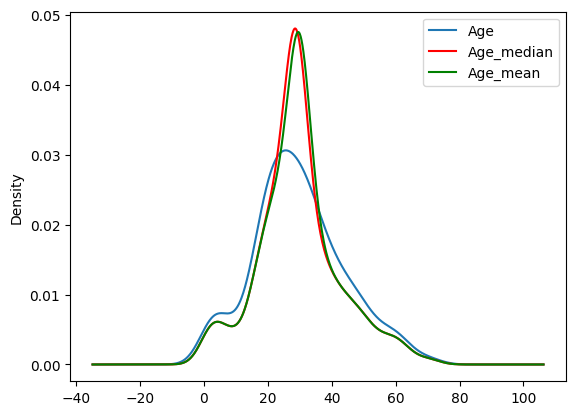

In [ ]:
fig=plt.figure()
ax=fig.add_subplot(111)
x_train['Age'].plot(kind='kde',ax=ax)
x_train['Age_median'].plot(kind='kde',ax=ax,color='red')
x_train['Age_mean'].plot(kind='kde',ax=ax,color='green')
lines,labels=ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

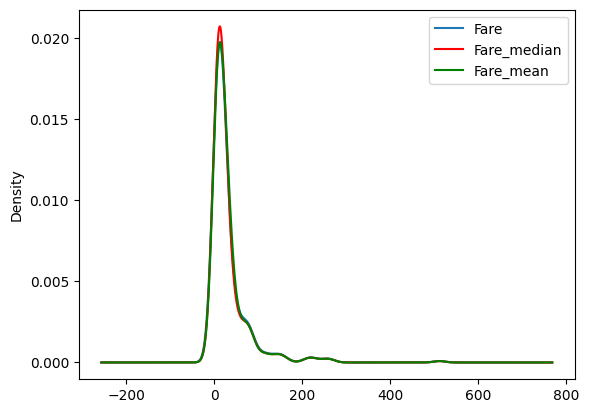

In [ ]:
fig=plt.figure()
ax=fig.add_subplot(111)
x_train['Fare'].plot(kind='kde',ax=ax)
x_train['Fare_median'].plot(kind='kde',ax=ax,color='red')
x_train['Fare_mean'].plot(kind='kde',ax=ax,color='green')
lines,labels=ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

In [ ]:
x_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,64.858859,66.665205
Fare,70.719262,2448.197914,17.258917,57.957599,55.603719,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-5.112563,-5.146106,16.476305,16.385048
Age_median,204.349513,57.957599,-5.112563,161.989566,161.812625,53.553455,55.023037
Age_mean,204.349513,55.603719,-5.146106,161.812625,161.812625,51.358000,52.788341
Fare_median,64.858859,2448.197914,16.476305,53.553455,51.358000,2340.091022,2324.238526
Fare_mean,66.665205,2448.197914,16.385048,55.023037,52.788341,2324.238526,2324.238526


In [ ]:
x_train.corr()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.087356,0.090156
Fare,0.092644,1.000000,0.208268,0.091757,0.088069,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.242883,-0.244610,0.205942,0.205499
Age_median,1.000000,0.091757,-0.242883,1.000000,0.999454,0.086982,0.089673
Age_mean,1.000000,0.088069,-0.244610,0.999454,1.000000,0.083461,0.086078
Fare_median,0.087356,1.000000,0.205942,0.086982,0.083461,1.000000,0.996607
Fare_mean,0.090156,1.000000,0.205499,0.089673,0.086078,0.996607,1.000000


<Axes: >

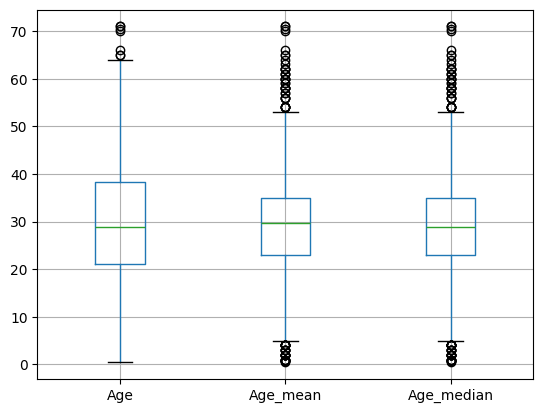

In [ ]:
x_train[['Age','Age_mean','Age_median']].boxplot()

<Axes: >

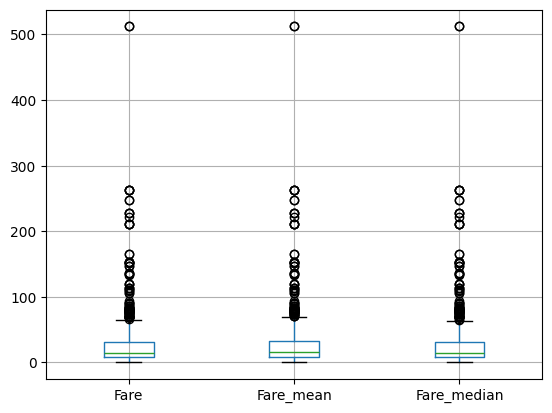

In [ ]:
x_train[['Fare','Fare_mean','Fare_median']].boxplot()

Yaha pe fare pe kr skate h but age pe nhi

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.2,random_state=2)

In [ ]:
imputer1=SimpleImputer(strategy='mean')
imputer2=SimpleImputer(strategy='median')

In [ ]:
trf1=ColumnTransformer([
    ('imputer1',imputer1,['Fare']),
    ('imputer2',imputer2,['Age'])
],remainder='passthrough')

In [ ]:
trf1.fit(x_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(), ['Fare']),
                                ('imputer2', SimpleImputer(strategy='median'),
                                 ['Age'])])

In [ ]:
trf1.named_transformers_['imputer1'].statistics_

array([39.26284643])

In [ ]:
trf1.named_transformers_['imputer2'].statistics_

array([28.])

# **Arbitary Value Inputation**

yaha pe ham ek arbitary no.(0,-1,99) se missing value ko change kr dete hai taaki ml model ko pata chal sake ki value nhi h waha pe


Benefit :- easy to apply

disadvantage :- similar to earlier

similar code rahega bass fillna me value use kr lenge jaise ki -1 or 99

aur simpleImputer me strategy="constant" aur fill_value=-1

# **End of value Distribution**

Similar case as of arbitary value
yaha pe distribution ke end ka koi value uthate ho

# **Categorical Data**

similar condition for uses as numerical and also the similar benefits and disadvantages

two ways:

1. most frequent
2. missing named

In [ ]:
df=pd.read_csv("train (3).csv",usecols=['GarageQual','FireplaceQu','SalePrice'])

In [ ]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [ ]:
df.isnull().mean()

,0
FireplaceQu,0.472603
GarageQual,0.055479
SalePrice,0.000000


Text(0, 0.5, 'Number of houses')

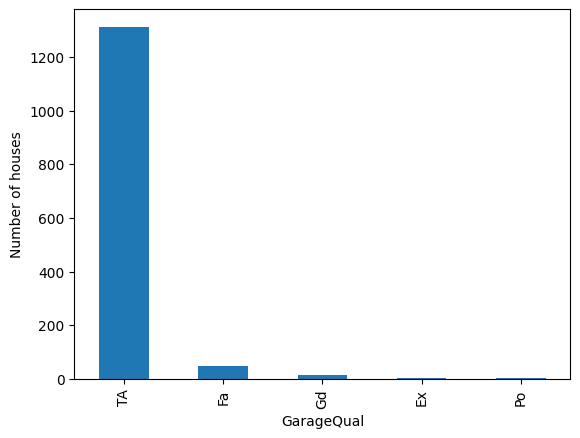

In [ ]:
df['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('GarageQual')
plt.ylabel('Number of houses')

Text(0.5, 1.0, 'GarageQual')

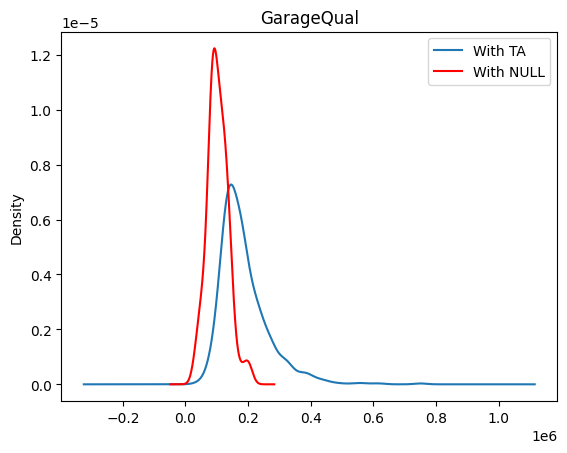

In [ ]:
fig=plt.figure()
ax=fig.add_subplot(111)
df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde',ax=ax)
df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde',ax=ax,color='red')
lines,labels=ax.get_legend_handles_labels()
labels=['With TA','With NULL']
ax.legend(lines,labels,loc='best')
plt.title('GarageQual')

In [ ]:
temp=df[df['GarageQual']=='TA']['SalePrice']

In [ ]:
df['GarageQual'].fillna('TA',inplace=True)

/tmp/ipython-input-584385255.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GarageQual'].fillna('TA',inplace=True)


<Axes: xlabel='GarageQual'>

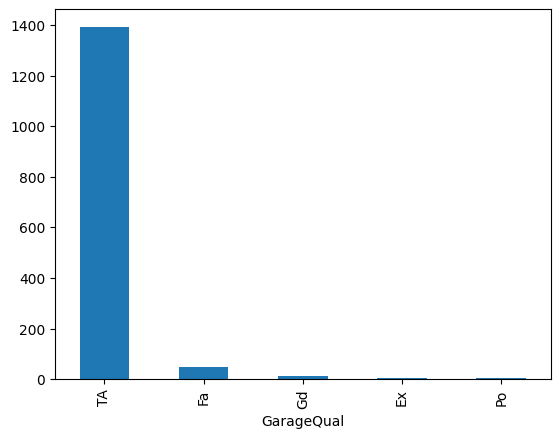

In [ ]:
df['GarageQual'].value_counts().plot.bar()

Text(0.5, 1.0, 'GarageQual')

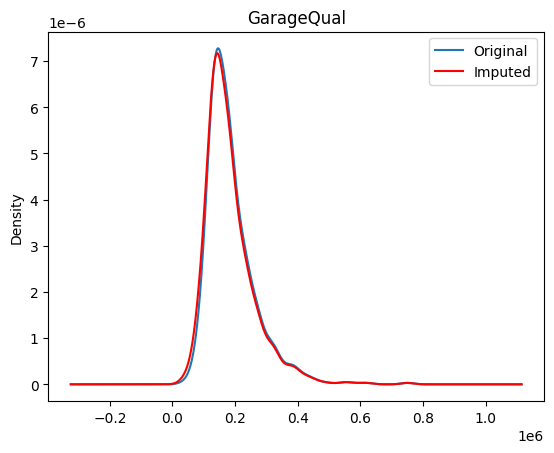

In [ ]:
fig=plt.figure()
ax=fig.add_subplot(111)
temp.plot(kind='kde',ax=ax)
df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde',ax=ax,color='red')
lines,labels=ax.get_legend_handles_labels()
labels=['Original','Imputed']
ax.legend(lines,labels,loc='best')
plt.title('GarageQual')

<Axes: xlabel='FireplaceQu'>

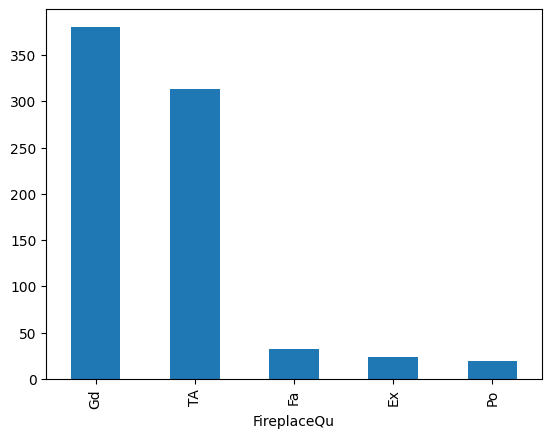

In [ ]:
df['FireplaceQu'].value_counts().plot.bar()

Text(0.5, 1.0, 'GarageQual')

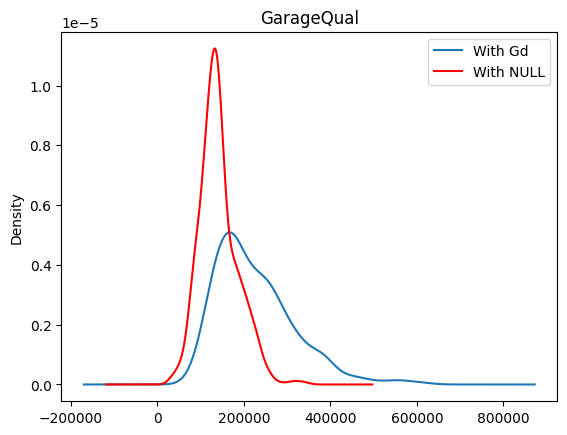

In [ ]:
fig=plt.figure()
ax=fig.add_subplot(111)
df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde',ax=ax)
df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde',ax=ax,color='red')
lines,labels=ax.get_legend_handles_labels()
labels=['With Gd','With NULL']
ax.legend(lines,labels,loc='best')
plt.title('GarageQual')

In [ ]:
temp=df[df['GarageQual']=='Gd']['SalePrice']

In [ ]:
df['FireplaceQu'].fillna('Gd',inplace=True)

<Axes: xlabel='FireplaceQu'>

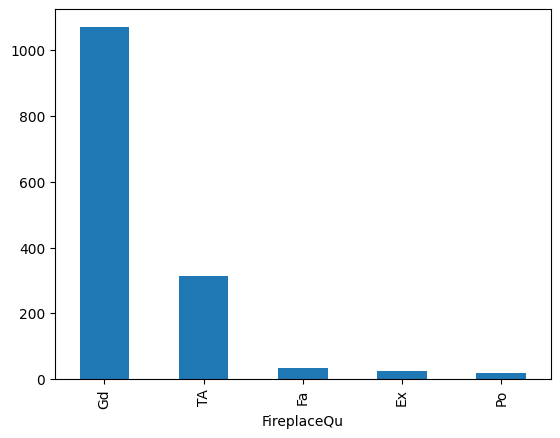

In [ ]:
df['FireplaceQu'].value_counts().plot.bar()

Text(0.5, 1.0, 'FirePlaceQu')

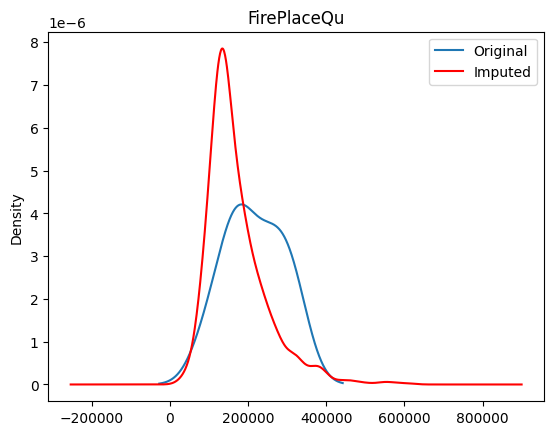

In [ ]:
fig=plt.figure()
ax=fig.add_subplot(111)
temp.plot(kind='kde',ax=ax)
df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde',ax=ax,color='red')
lines,labels=ax.get_legend_handles_labels()
labels=['Original','Imputed']
ax.legend(lines,labels,loc='best')
plt.title('FirePlaceQu')